<a href="https://colab.research.google.com/github/JonPaulBIlbao/ML-Finance-DBS/blob/Machine-Learning-in-Finance-DBS/Titanic_Colab_R_Notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛳️ Titanic Survival Prediction in R

This notebook implements a machine learning pipeline using CHAID and CART decision trees to predict survival on the Titanic dataset. The code is written in **R** and follows a structured teaching format.

## 1. Setup and Package Installation

In [8]:
required_packages <- c("ggplot2")
missing <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if (length(missing)) install.packages(missing)
invisible(lapply(required_packages, library, character.only = TRUE))
cat("Loaded packages:", paste(required_packages, collapse = ", "), "\n")

Loaded packages: ggplot2 


In [9]:
# Install devtools to download from R-Forge
install.packages("devtools")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [11]:
install.packages("partykit")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘libcoin’, ‘mvtnorm’, ‘Formula’, ‘inum’




In [12]:
devtools::install_url("https://r-forge.r-project.org/src/contrib/CHAID_0.1-2.tar.gz",
                      repos = NULL, type = "source")

Skipping 1 packages not available: partykit



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpjRTjEd/remotes11755c7eaef7/CHAID/DESCRIPTION’ ... OK
* preparing ‘CHAID’:
* checking DESCRIPTION meta-information ... OK
* running ‘cleanup’
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘CHAID_0.1-2.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [13]:
library(CHAID)

Loading required package: partykit

Loading required package: grid

Loading required package: libcoin

Loading required package: mvtnorm



## 2. Load Titanic Training Data
We load the training dataset and inspect its structure.

In [29]:
titanic_train <- read.csv(
  "https://raw.githubusercontent.com/JonPaulBIlbao/ML-Finance-DBS/Machine-Learning-in-Finance-DBS/decision_trees/train.csv",
  stringsAsFactors = TRUE
)
summary(titanic_train)
str(titanic_train)

  PassengerId       Survived          Pclass     
 Min.   :  1.0   Min.   :0.0000   Min.   :1.000  
 1st Qu.:223.5   1st Qu.:0.0000   1st Qu.:2.000  
 Median :446.0   Median :0.0000   Median :3.000  
 Mean   :446.0   Mean   :0.3838   Mean   :2.309  
 3rd Qu.:668.5   3rd Qu.:1.0000   3rd Qu.:3.000  
 Max.   :891.0   Max.   :1.0000   Max.   :3.000  
                                                 
                                    Name         Sex           Age       
 Abbing, Mr. Anthony                  :  1   female:314   Min.   : 0.42  
 Abbott, Mr. Rossmore Edward          :  1   male  :577   1st Qu.:20.12  
 Abbott, Mrs. Stanton (Rosa Hunt)     :  1                Median :28.00  
 Abelson, Mr. Samuel                  :  1                Mean   :29.70  
 Abelson, Mrs. Samuel (Hannah Wizosky):  1                3rd Qu.:38.00  
 Adahl, Mr. Mauritz Nils Martin       :  1                Max.   :80.00  
 (Other)                              :885                NA's   :177    
     Sib

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : Factor w/ 891 levels "Abbing, Mr. Anthony",..: 109 191 358 277 16 559 520 629 417 581 ...
 $ Sex        : Factor w/ 2 levels "female","male": 2 1 1 1 2 2 2 2 1 1 ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : Factor w/ 681 levels "110152","110413",..: 524 597 670 50 473 276 86 396 345 133 ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : Factor w/ 148 levels "","A10","A14",..: 1 83 1 57 1 1 131 1 1 1 ...
 $ Embarked   : Factor w/ 4 levels "","C","Q","S": 4 2 4 4 4 3 4 4 4 2 ...


## 3. Data Preparation
Convert variables and explore survival by sex.

In [30]:
titanic_train$Survived <- as.factor(titanic_train$Survived)
str(titanic_train)

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : Factor w/ 2 levels "0","1": 1 2 2 2 1 1 1 1 2 2 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : Factor w/ 891 levels "Abbing, Mr. Anthony",..: 109 191 358 277 16 559 520 629 417 581 ...
 $ Sex        : Factor w/ 2 levels "female","male": 2 1 1 1 2 2 2 2 1 1 ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : Factor w/ 681 levels "110152","110413",..: 524 597 670 50 473 276 86 396 345 133 ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : Factor w/ 148 levels "","A10","A14",..: 1 83 1 57 1 1 131 1 1 1 ...
 $ Embarked   : Factor w/ 4 levels "","C","Q","S": 4 2 4 4 4 3 4 4 4 2 ...


In [31]:
table(titanic_train$Survived, titanic_train$Sex)
chisq.test(titanic_train$Survived, titanic_train$Sex)
prop.table(table(titanic_train$Survived, titanic_train$Sex), margin = 2) * 100

   
    female male
  0     81  468
  1    233  109


	Pearson's Chi-squared test with Yates' continuity correction

data:  titanic_train$Survived and titanic_train$Sex
X-squared = 260.72, df = 1, p-value < 2.2e-16


   
      female     male
  0 25.79618 81.10919
  1 74.20382 18.89081

## 4. Family Onboard Indicators
Visualize and create a new feature for traveling alone.


  0   1   2   3   4   5   8 
608 209  28  16  18   5   7 


  0   1   2   3   4   5   6 
678 118  80   5   4   5   1 

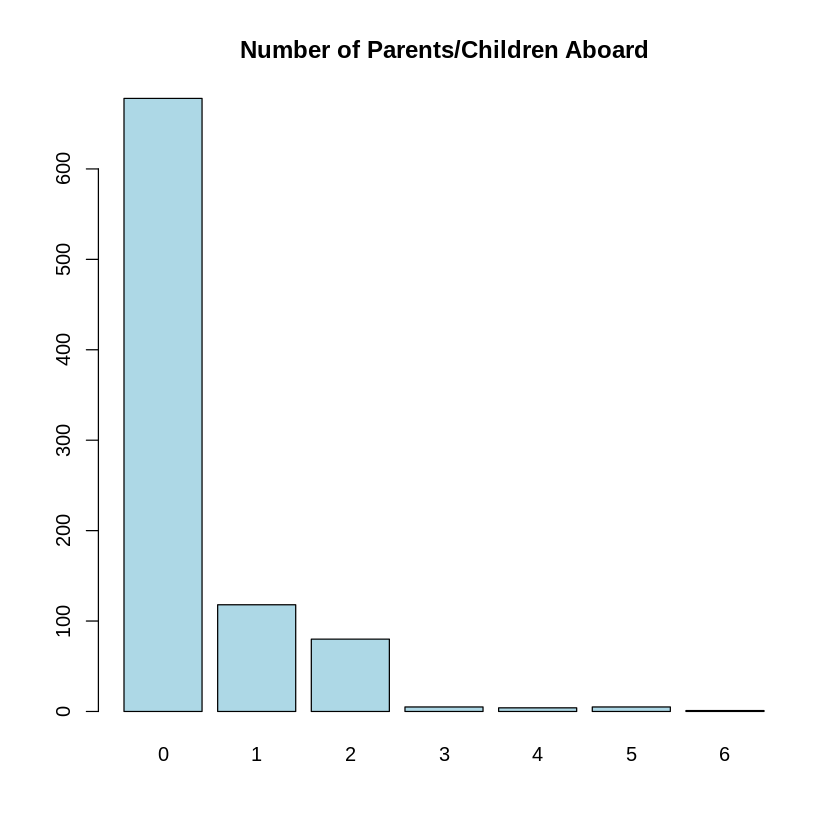

   
    Not Alone    Alone
  0  49.43503 69.64618
  1  50.56497 30.35382


	Pearson's Chi-squared test with Yates' continuity correction

data:  titanic_train$Survived and titanic_train$Alone
X-squared = 36.001, df = 1, p-value = 1.973e-09


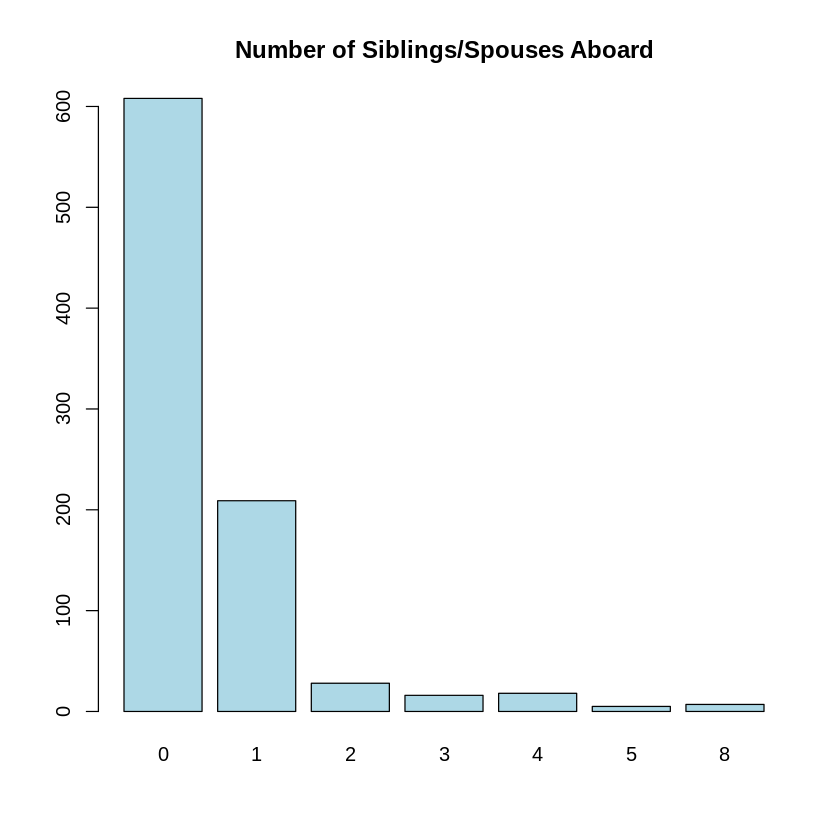

In [32]:
table(titanic_train$SibSp)
table(titanic_train$Parch)
barplot(table(titanic_train$Parch), main = "Number of Parents/Children Aboard", col = "lightblue")
barplot(table(titanic_train$SibSp), main = "Number of Siblings/Spouses Aboard", col = "lightblue")
titanic_train$Alone <- ifelse(titanic_train$Parch == 0 & titanic_train$SibSp == 0, 1, 0)
titanic_train$Alone <- factor(titanic_train$Alone, labels = c("Not Alone", "Alone"))
prop.table(table(titanic_train$Survived, titanic_train$Alone), margin = 2) * 100
chisq.test(titanic_train$Survived, titanic_train$Alone)

## 5. CHAID Decision Tree
Build and visualize a CHAID tree to predict survival.


Model formula:
Survived ~ Sex + Embarked

Fitted party:
[1] root
|   [2] Sex in female
|   |   [3] Embarked in , C: 1 (n = 75, err = 12.0%)
|   |   [4] Embarked in Q, S: 1 (n = 239, err = 30.1%)
|   [5] Sex in male
|   |   [6] Embarked in , C: 0 (n = 95, err = 30.5%)
|   |   [7] Embarked in Q, S: 0 (n = 482, err = 16.6%)

Number of inner nodes:    3
Number of terminal nodes: 4


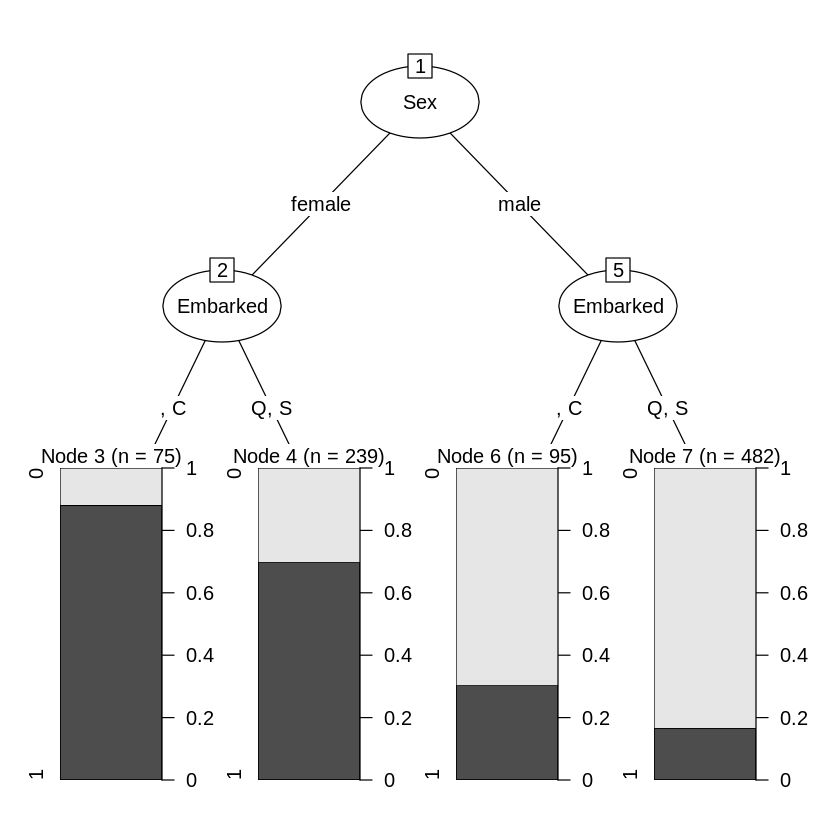

In [33]:
chaidtitanic <- chaid(Survived ~ Sex + Embarked, data = titanic_train)
print(chaidtitanic)
plot(chaidtitanic)

## 6. Refine CHAID Model with Pclass
Add `Pclass` to improve the model.


Model formula:
Survived ~ Sex + Embarked + PclassF

Fitted party:
[1] root
|   [2] Sex in female
|   |   [3] PclassF in 1, 2: 1 (n = 170, err = 5.3%)
|   |   [4] PclassF in 3
|   |   |   [5] Embarked in , C, Q: 1 (n = 56, err = 30.4%)
|   |   |   [6] Embarked in S: 0 (n = 88, err = 37.5%)
|   [7] Sex in male
|   |   [8] PclassF in 1: 0 (n = 122, err = 36.9%)
|   |   [9] PclassF in 2, 3: 0 (n = 455, err = 14.1%)

Number of inner nodes:    4
Number of terminal nodes: 5


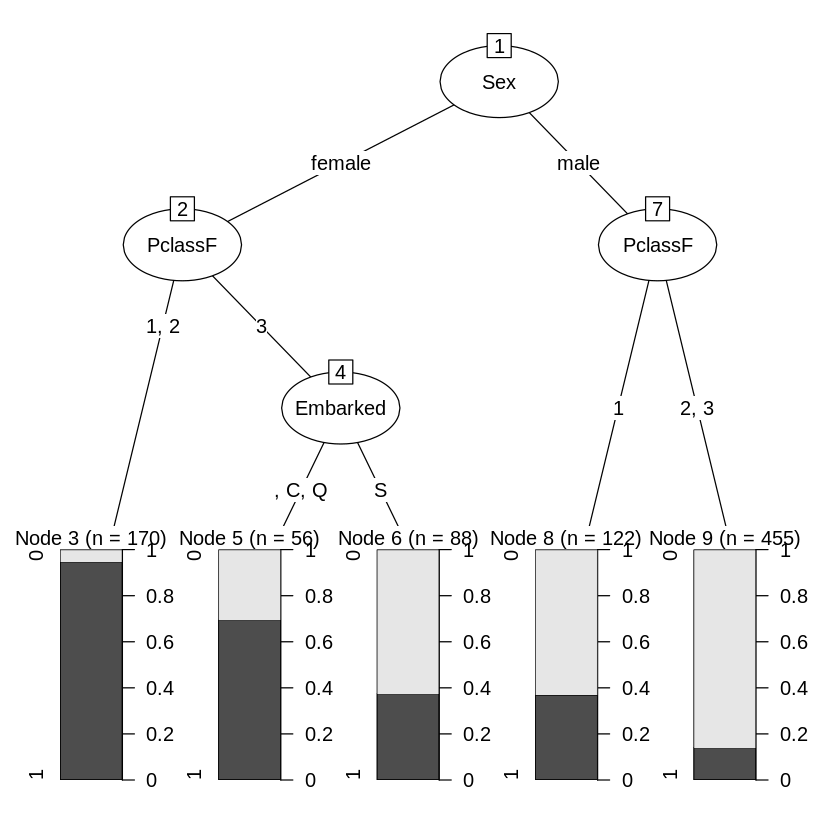

In [34]:
titanic_train$PclassF <- factor(titanic_train$Pclass, order=TRUE)
chaidtitanic <- chaid(Survived ~ Sex + Embarked + PclassF, data = titanic_train)
print(chaidtitanic)
plot(chaidtitanic)

## 7. Predict on Titanic Test Set

In [35]:
titanic_test <- read.csv(
  "https://raw.githubusercontent.com/JonPaulBIlbao/ML-Finance-DBS/Machine-Learning-in-Finance-DBS/decision_trees/test.csv",
  stringsAsFactors = TRUE
)
titanic_test$PclassF <- factor(titanic_test$Pclass, order=TRUE)
titanic_test$SurvivedP <- predict(chaidtitanic, titanic_test)
table(titanic_test$Sex, titanic_test$SurvivedP)

        
           0   1
  female  41 111
  male   266   0

## 8. CHAID Extended with Parch

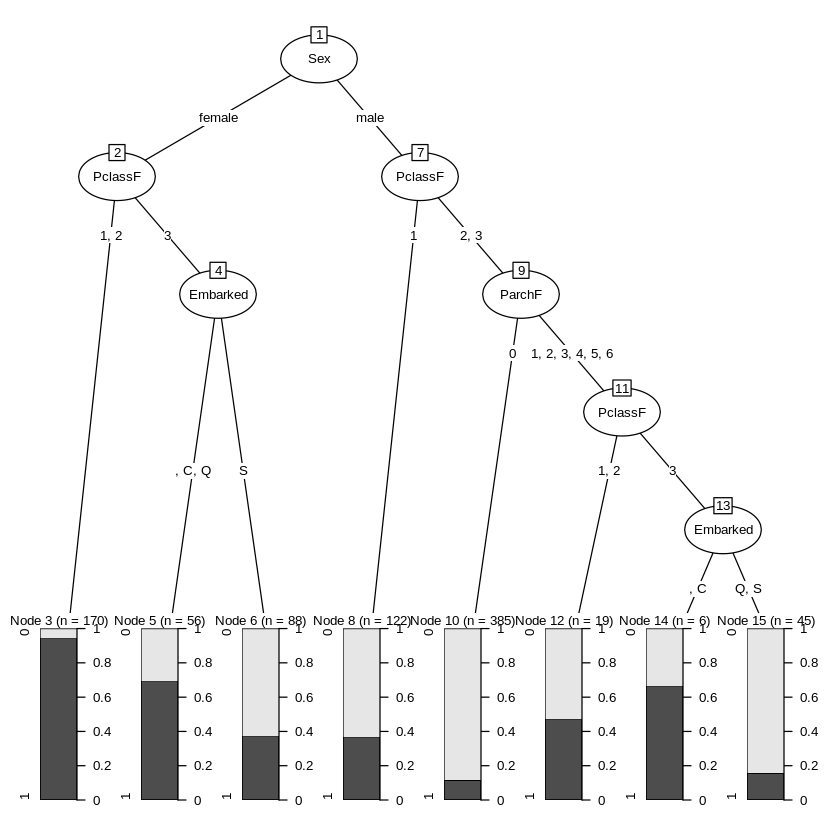

In [37]:
titanic_train$ParchF <- factor(titanic_train$Parch, order=TRUE)
chaidtitanic2 <- chaid(Survived ~ Sex + Embarked + PclassF + ParchF, data = titanic_train)
plot(chaidtitanic2, compress = TRUE, uniform = TRUE, gp = gpar(fontsize = 8))

## 9. Fix Test Data and Predict Again

In [38]:
titanic_test$Parch <- ifelse(titanic_test$Parch == 9, 6, titanic_test$Parch)
titanic_test$ParchF <- factor(titanic_test$Parch, order=TRUE)
titanic_test$SurvivedP <- predict(chaidtitanic2, titanic_test)
summary(titanic_test$SurvivedP)

0   1 
302 116

## 10. CART Models: tree0 (Default) and tree1 (Tuned)

In [ ]:
tree0 <- rpart(Survived ~ Sex + Embarked + Parch + SibSp + Pclass + Embarked,
                data = titanic_train, parms = list(split = "information"))
rpart.plot(tree0, type = 2, extra = 101, tweak = 1.2)

## 11. Deeper CART Tree with Tuning

In [ ]:
%%R
tree1 <- rpart(Survived ~ Sex + Embarked + Parch + SibSp + Pclass,
               data = titanic_train,
               parms = list(split = "information"),
               control = rpart.control(cp = 0.001, minsplit = 10))
rpart.plot(tree1, type = 4, extra = 106, box.palette = "BuGn", tweak = 1.2, cex = 0.5)

## 12. Prediction Comparison: tree0 vs tree1

In [ ]:
%%R
titanic_test$pred_class_tree0 <- predict(tree0, newdata = titanic_test, type = "class")
titanic_test$pred_class_tree1 <- predict(tree1, newdata = titanic_test, type = "class")
table(titanic_test$pred_class_tree0, titanic_test$pred_class_tree1)